In [88]:
import pandas as pd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import TensorDataset, DataLoader

In [89]:
data = pd.read_csv("juice.csv")
data.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [90]:
data.shape
# je controle la taille de mon dataset

(4898, 12)

In [91]:
data.dtypes
# puis je verifie si tout les types convienes au valeur du tableau

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

C:\Users\llien\AppData\Local\Temp\ipykernel_27348\874074562.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


<Figure size 640x480 with 0 Axes>

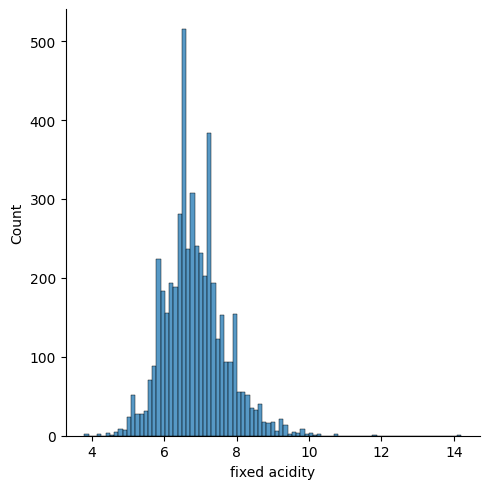

<Figure size 640x480 with 0 Axes>

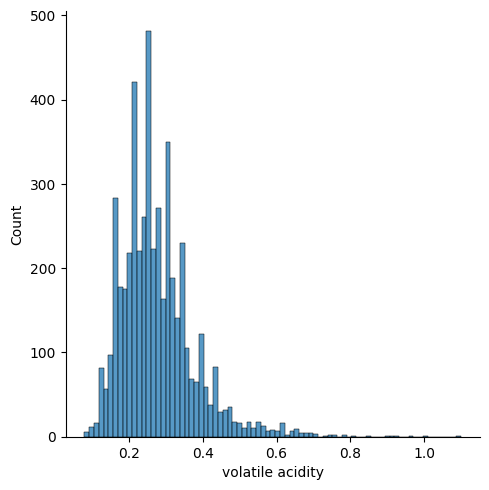

<Figure size 640x480 with 0 Axes>

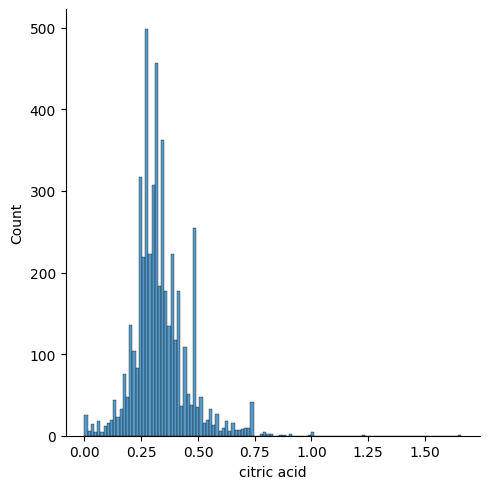

<Figure size 640x480 with 0 Axes>

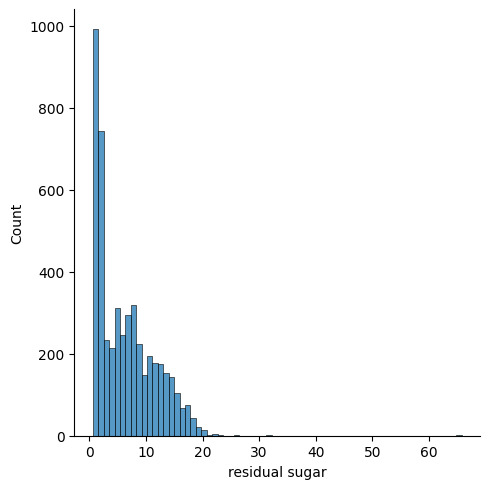

<Figure size 640x480 with 0 Axes>

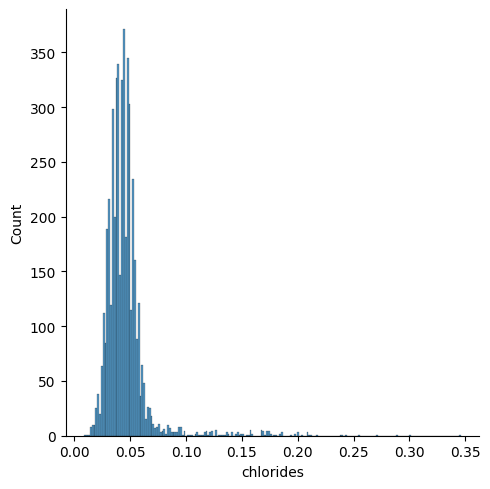

<Figure size 640x480 with 0 Axes>

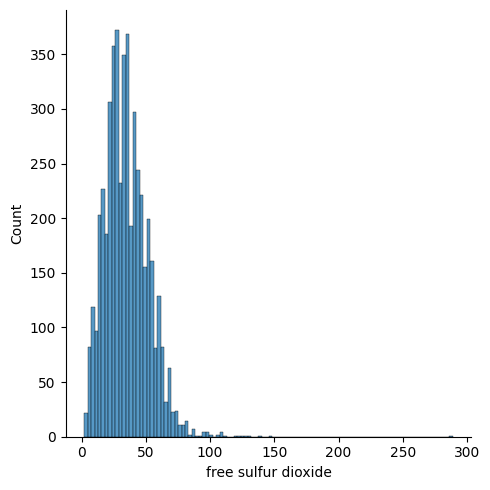

<Figure size 640x480 with 0 Axes>

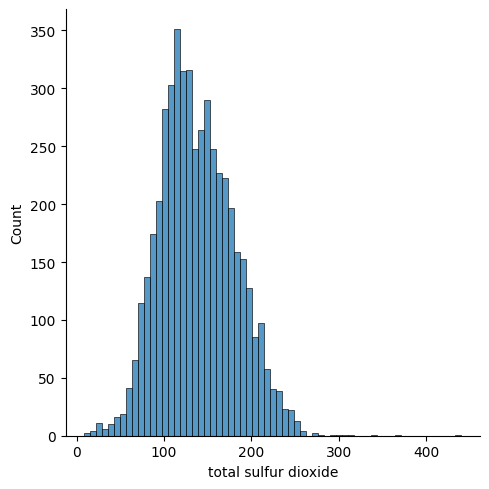

<Figure size 640x480 with 0 Axes>

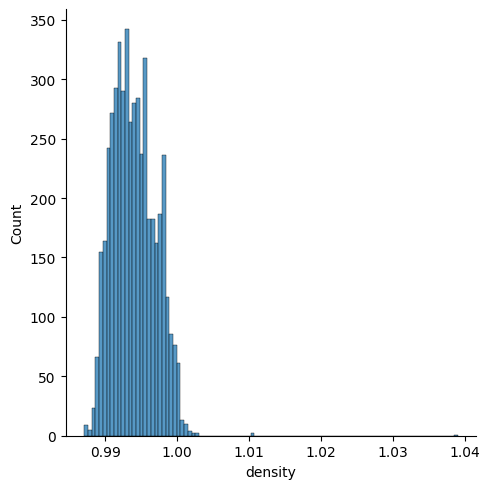

<Figure size 640x480 with 0 Axes>

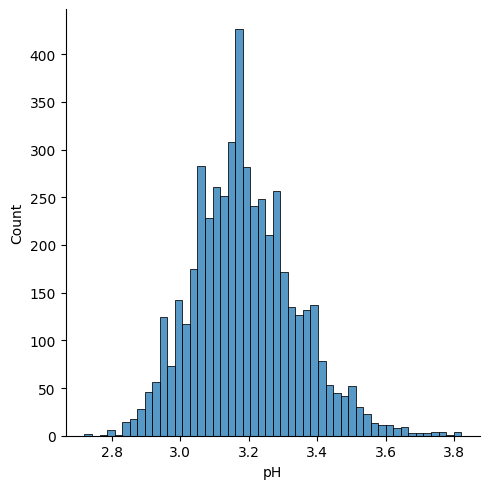

<Figure size 640x480 with 0 Axes>

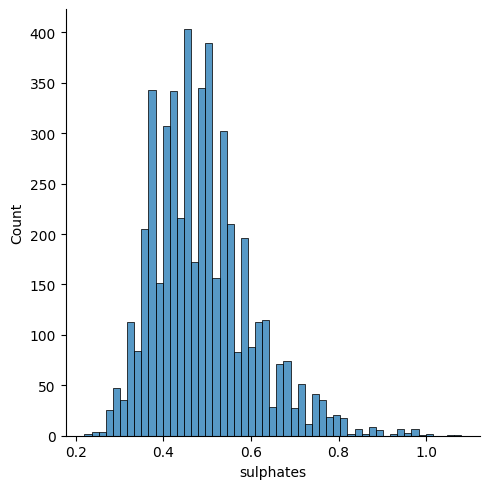

<Figure size 640x480 with 0 Axes>

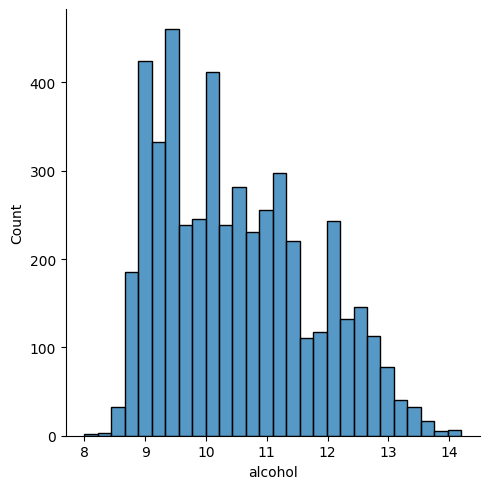

<Figure size 640x480 with 0 Axes>

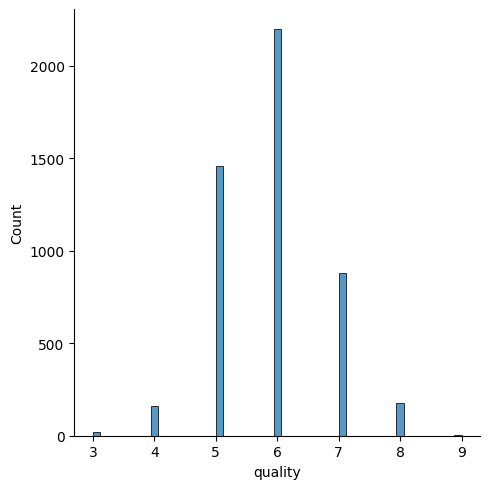

In [92]:
for col in data.select_dtypes(include={'float','int'}):
    plt.figure()
    sns.displot(data[col])
# je vois la repartition des données de chaque colone

In [93]:
D_ligne= data[data.duplicated()]
D_ligne
# je recherche les lignes dupliqués

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.900000,6
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.100000,6
7,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.800000,6
8,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.500000,6
20,6.2,0.66,0.48,1.2,0.029,29.0,75.0,0.98920,3.33,0.39,12.800000,8
...,...,...,...,...,...,...,...,...,...,...,...,...
4828,6.4,0.23,0.35,10.3,0.042,54.0,140.0,0.99670,3.23,0.47,9.200000,5
4850,7.0,0.36,0.35,2.5,0.048,67.0,161.0,0.99146,3.05,0.56,11.100000,6
4851,6.4,0.33,0.44,8.9,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,5
4856,7.1,0.23,0.39,13.7,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6


In [94]:
data=data.drop_duplicates()
# je supprime les doublons trouveés

In [95]:
data['quality'].value_counts()

quality
6    1788
5    1175
7     689
4     153
8     131
3      20
9       5
Name: count, dtype: int64

In [96]:
data.isna().sum()
# je recherche les valeurs manquantes dans le jeu de données
# et je constate que mon dataset na pas de valeur manquante

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

<Axes: >

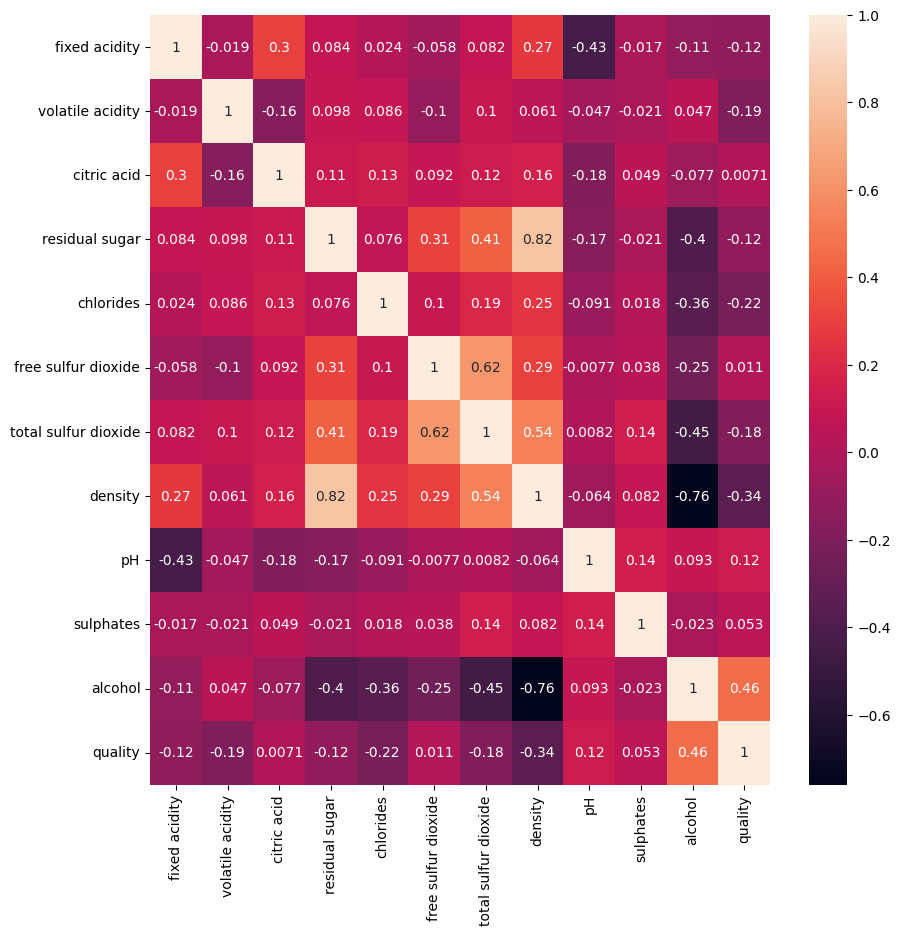

In [97]:
# Afficher la matrice de corrélation
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(),annot=True)
# et je vois dans ma matrique qu'il n'y a pas de colones fortements 

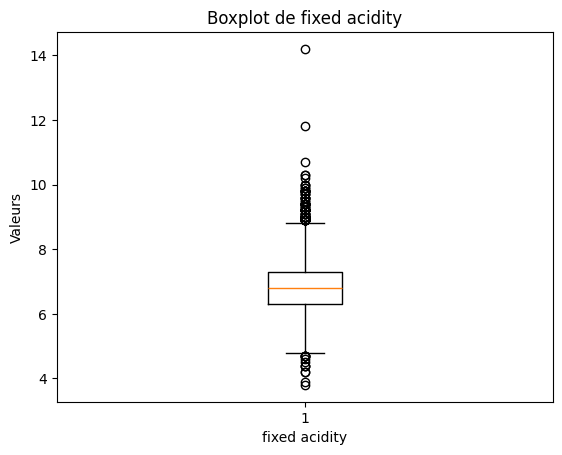

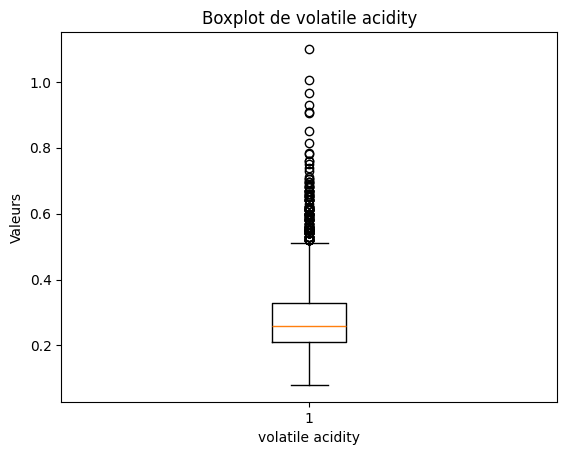

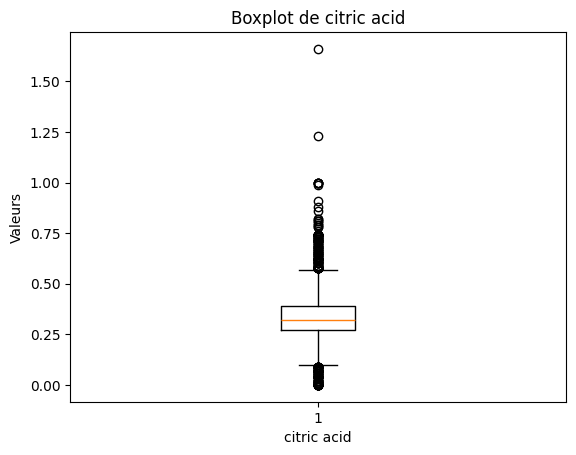

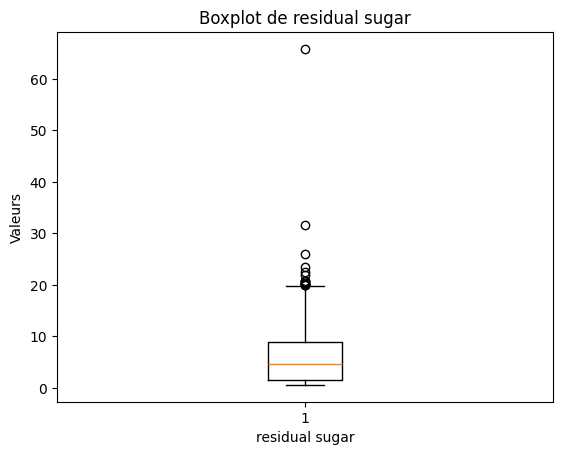

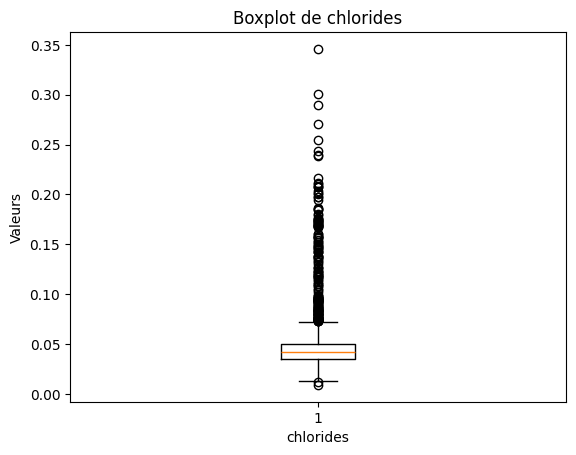

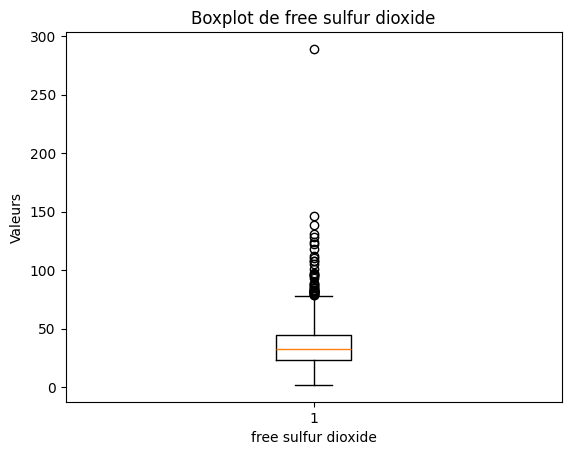

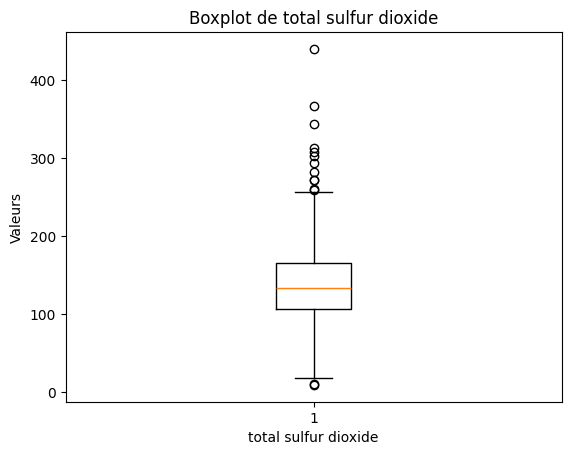

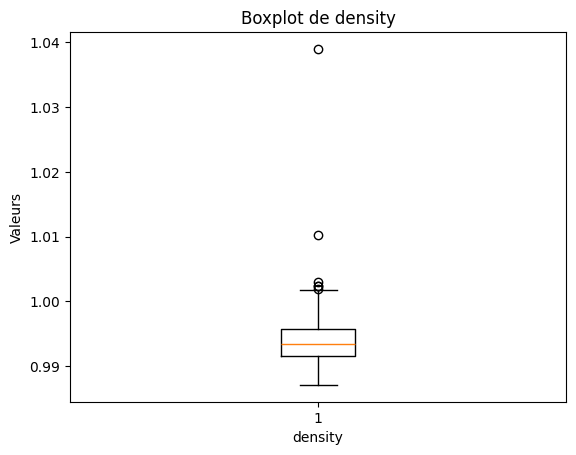

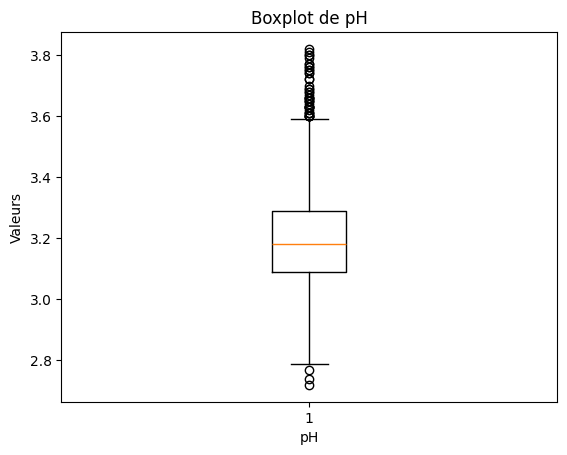

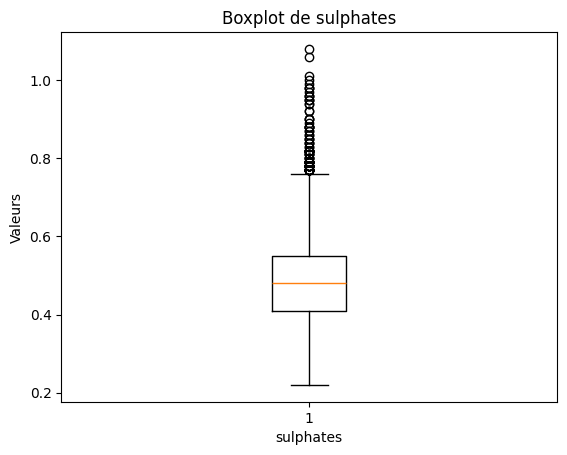

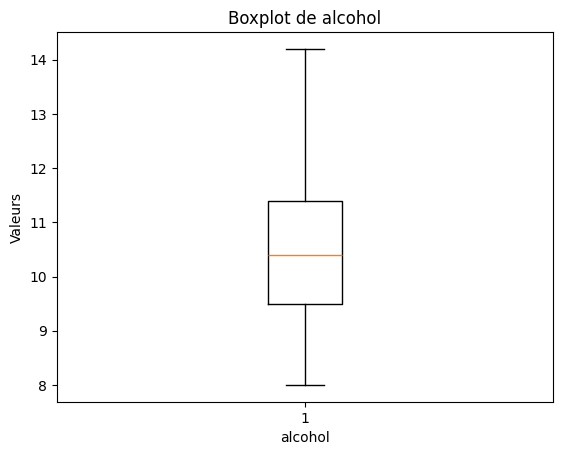

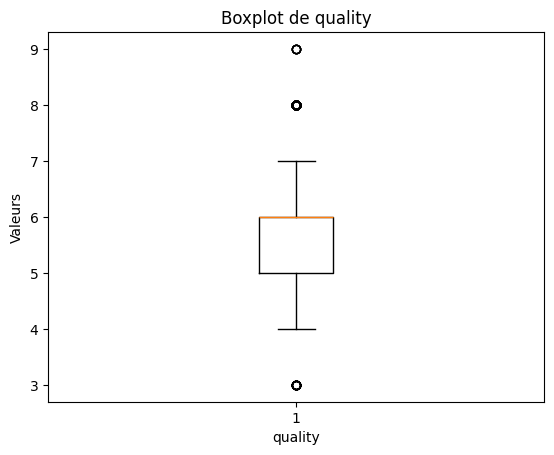

In [98]:
num = data.select_dtypes(include=['int', 'float']).columns

for co in num:
    plt.boxplot(data[co])
    plt.title(f'Boxplot de {co}')
    plt.xlabel(co)
    plt.ylabel('Valeurs')
    plt.show()


In [99]:
# Avant le split
#data['quality'] = data['quality'].replace({3:0, 4:0, 5:0, 6:1, 7:1, 8:2, 9:2})
# Avant le split Train/Test
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 6 else 0)

0 (Médiocre) : notes 3, 4

1 (Bon) : notes 5, 6

2 (Tres bon): notes 7, 8

3 (Excellent) : notes 9

In [100]:
X = data.drop('quality', axis=1)
y = data['quality']

In [101]:
data['quality'].value_counts()

quality
1    2613
0    1348
Name: count, dtype: int64

In [102]:
# 2. Split Train/Test (Important : On garde le test pur)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [103]:
# 3. Rééquilibrage uniquement sur le Train set
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

In [104]:
X_train.value_counts()

fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density   pH        sulphates  alcohol  
11.800000      0.230000          0.380000     11.100000       0.034000   15.000000            123.000000            0.999700  2.930000  0.550000   9.700000     1
3.800000       0.310000          0.020000     11.100000       0.036000   20.000000            114.000000            0.992480  3.750000  0.440000   12.400000    1
9.800000       0.160000          0.460000     1.800000        0.046000   23.000000            130.000000            0.995870  3.040000  0.670000   9.600000     1
9.795620       0.359848          0.449924     1.599429        0.042004   11.000000            124.003809            0.994397  2.930667  0.459981   10.799048    1
9.700000       0.240000          0.490000     4.900000        0.032000   3.000000             18.000000             0.993680  2.850000  0.540000   10.000000    1
                                 

In [105]:
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Standardisation des données
sc = RobustScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [106]:
#from sklearn.decomposition import PCA

# On garde assez de composantes pour expliquer 95% de la variance
#pca = PCA(n_components=4) 

In [107]:
#X_train_pca = pca.fit_transform(X_train_sc)
#X_test_pca = pca.transform(X_test_sc)

# N'oublie pas de mettre à jour la taille d'entrée de ton modèle
# input_shape = X_train_pca.shape[1]

In [108]:
X_train_t = torch.tensor(X_train_sc,dtype=torch.float32)
X_test_t = torch.tensor(X_test_sc,dtype=torch.float32)
y_train_t = torch.tensor(y_train_encoded,dtype=torch.float32)
y_test_t = torch.tensor(y_test_encoded,dtype=torch.float32)

In [109]:
from torch import nn

class WineQualityModel(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=input_shape, out_features=16)
        self.bn1 = nn.BatchNorm1d(16)
        self.layer_2 = nn.Linear(in_features=16, out_features=16)
        self.bn2 = nn.BatchNorm1d(16)
        self.dropout = nn.Dropout(0.2) # Augmenté légèrement pour la régularisation
        self.layer_3 = nn.Linear(in_features=16, out_features=2) # 2 classes : 0 ou 1
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.bn1(self.layer_1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.layer_2(x)))
        x = self.layer_3(x)
        return x

# Instanciation
model = WineQualityModel(input_shape=X_train_t.shape[1])

model

WineQualityModel(
  (layer_1): Linear(in_features=11, out_features=16, bias=True)
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer_2): Linear(in_features=16, out_features=16, bias=True)
  (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (layer_3): Linear(in_features=16, out_features=2, bias=True)
  (relu): ReLU()
)

In [110]:
# Vérification rapide avant de lancer l'entraînement
print(y_train_t.dtype) # Doit afficher torch.int64 (ou Long)
print(torch.unique(y_train_t)) # Doit afficher tensor([0, 1])

torch.float32
tensor([0., 1.])


In [111]:
# 1. Fonction de perte : Idéale pour la classification multiclasse
loss_fn = nn.CrossEntropyLoss()

# 2. Optimiseur : Adam est souvent plus performant que SGD pour débuter
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                       mode='min', 
                                                       factor=0.1, 
                                                       patience=5, 
                                                       verbose=True)

c:\Code\IA\DL\Pytorch\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [112]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

In [113]:
# S'assurer que les labels sont des entiers Long avant de commencer
y_train_t = y_train_t.long()
y_test_t = y_test_t.long()

# Listes pour le monitoring
epoch_count = []
train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []

torch.manual_seed(42)
epochs = 700 # 20 000 peut être beaucoup, commencez par 2000 pour tester

for epoch in range(epochs):
    # --- MODE TRAINING ---
    model.train()
    
    # 1. Forward pass (on garde les logits bruts pour la loss)
    y_logits = model(X_train_t) 
    
    # 2. Prédictions : on prend l'index de la valeur maximale sur la dimension des classes (dim=1)
    y_pred = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
    
    # 3. Calcul de la Loss (CrossEntropyLoss prend les logits directement)
    loss = loss_fn(y_logits, y_train_t)
    acc = accuracy_fn(y_train_t, y_pred)
    
    # 4. Optimizer
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # --- MODE TESTING ---
    model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model(X_test_t)
        
        # 2. Prédictions test
        test_pred = torch.argmax(torch.softmax(test_logits, dim=1), dim=1)
        
        # 3. Loss et Acc
        # ... à la fin du bloc "with torch.inference_mode():"
        test_loss = loss_fn(test_logits, y_test_t)

    # On donne la loss de test au scheduler pour qu'il décide de réduire ou non
        scheduler.step(test_loss)
        test_acc = accuracy_fn(y_test_t, test_pred)

        # Monitoring
        if epoch % 100 == 0:
            epoch_count.append(epoch)
            train_acc_list.append(acc)
            test_acc_list.append(test_acc)
            # On utilise .item() pour stocker un chiffre et non un tenseur complet
            train_loss_list.append(loss.item())
            test_loss_list.append(test_loss.item())

            print(f'Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%')

Epoch: 0 | Loss: 0.73136 | Acc: 47.03% | Test Loss: 0.70070 | Test Acc: 44.01%
Epoch: 100 | Loss: 0.48803 | Acc: 76.38% | Test Loss: 0.55436 | Test Acc: 71.63%
Epoch: 200 | Loss: 0.49036 | Acc: 77.02% | Test Loss: 0.55379 | Test Acc: 71.75%
Epoch: 300 | Loss: 0.49266 | Acc: 76.81% | Test Loss: 0.55375 | Test Acc: 71.75%
Epoch: 400 | Loss: 0.49387 | Acc: 76.81% | Test Loss: 0.55338 | Test Acc: 71.88%
Epoch: 500 | Loss: 0.49359 | Acc: 76.76% | Test Loss: 0.55393 | Test Acc: 71.75%
Epoch: 600 | Loss: 0.49435 | Acc: 76.62% | Test Loss: 0.55382 | Test Acc: 71.75%


C:\Users\llien\AppData\Local\Temp\ipykernel_27348\600445384.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  train_acc_list = np.array(torch.tensor(train_acc_list))
C:\Users\llien\AppData\Local\Temp\ipykernel_27348\600445384.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_acc_list = np.array(torch.tensor(test_acc_list))


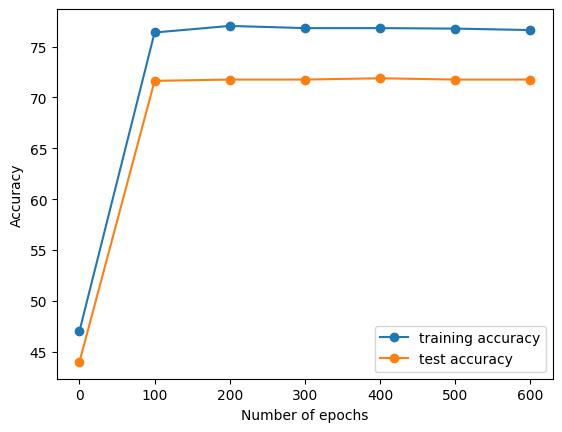

In [114]:
#Revert to NP ARRAY
train_acc_list = np.array(torch.tensor(train_acc_list))
test_acc_list = np.array(torch.tensor(test_acc_list))

plt.plot(epoch_count,train_acc_list,label='training accuracy',marker='o')
plt.plot(epoch_count,test_acc_list,label='test accuracy',marker='o')
plt.xlabel('Number of epochs')
plt.ylabel('Accuracy')
plt.legend()

C:\Users\llien\AppData\Local\Temp\ipykernel_27348\948965976.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  train_loss_list = np.array(torch.tensor(train_loss_list))
C:\Users\llien\AppData\Local\Temp\ipykernel_27348\948965976.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_loss_list = np.array(torch.tensor(test_loss_list))


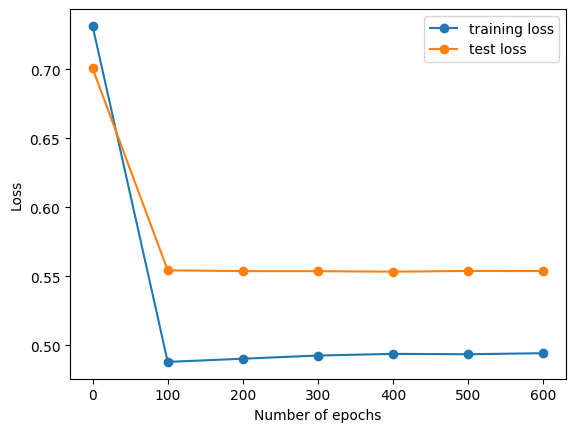

In [115]:
train_loss_list = np.array(torch.tensor(train_loss_list))
test_loss_list = np.array(torch.tensor(test_loss_list))

plt.plot(epoch_count,train_loss_list,label='training loss',marker='o')
plt.plot(epoch_count,test_loss_list,label='test loss',marker='o')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.legend()

<Axes: >

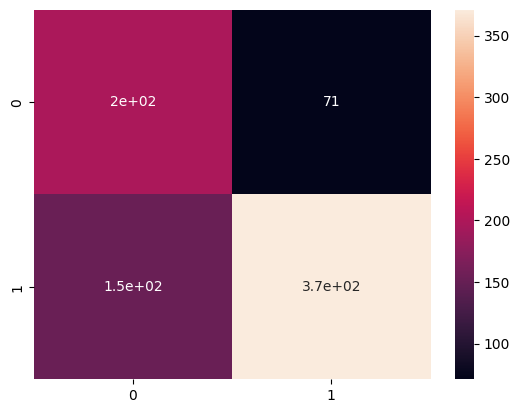

In [116]:
from sklearn.metrics import confusion_matrix
model_matrix = confusion_matrix(y_test,test_pred)
sns.heatmap(model_matrix,annot=True)

<Axes: >

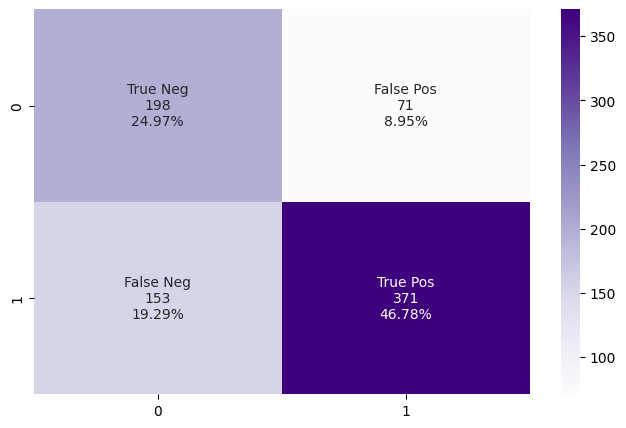

In [117]:
# Visualize
fig, ax = plt.subplots(figsize=(8,5))
# setting variables
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ['{0:0.0f}'.format(value) for value in model_matrix.flatten()]
group_percentages = ['{0:.2%}'.format(value) for value in model_matrix.flatten()/np.sum(model_matrix)]
labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(model_matrix, annot=labels, fmt='', cmap='Purples')

In [118]:
model.eval()
# On crée une entrée qui ressemble à une ligne de tes données
example_input = torch.rand(1, X_train_t.shape[1]) 

# Tracé et sauvegarde
traced_script_module = torch.jit.trace(model, example_input)
traced_script_module.save("wine_model_final.pt")

print("Modèle sauvegardé avec succès !")

Modèle sauvegardé avec succès !


In [119]:
import joblib
joblib.dump(sc, "wine_scaler.pkl")

['wine_scaler.pkl']